# Delivery Route Optimization System

This project simulates a real-world logistics problem where delivery routes are optimized using multiple algorithmic strategies.

The system integrates:
- Greedy Algorithm (Parcel Selection)
- Dynamic Programming (Time Constraints)
- Graph Algorithms (Dijkstra & MST)
- Traveling Salesman Problem (TSP)
- Recursion (Route Cost Estimation)

The goal is to balance efficiency, cost, and constraints in delivery planning.

In [50]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [51]:
from src.graph_utils import dijkstra
from src.greedy import select_parcels
from src.tsp import tsp
from src.dp import check_time_constraints
from src.recursion import recursive_cost
from src.graph_utils import prim_mst

import matplotlib.pyplot as plt
import networkx as nx
import time

In [52]:
# time measuring function

def measure_time_avg(func, *args, runs=1000):
    total = 0
    for _ in range(runs):
        start = time.perf_counter()
        func(*args)
        end = time.perf_counter()
        total += (end - start)
    return total / runs

##  Input Modeling

We define the problem using:
- A graph representing distances between locations
- Parcel data including value, weight, and delivery deadlines
- Vehicle constraints such as maximum capacity

This structured input allows us to apply different algorithms effectively.

In [53]:
graph = {
    'Warehouse': {'A': 10, 'B': 15, 'C': 20},
    'A': {'Warehouse': 10, 'B': 35, 'C': 25},
    'B': {'Warehouse': 15, 'A': 35, 'C': 30},
    'C': {'Warehouse': 20, 'A': 25, 'B': 30}
}

parcels = [
    {'id': 1, 'location': 'A', 'value': 100, 'weight': 5, 'deadline': 15},
    {'id': 2, 'location': 'B', 'value': 60, 'weight': 3, 'deadline': 10},
    {'id': 3, 'location': 'C', 'value': 120, 'weight': 7, 'deadline': 20}
]

vehicle = {'capacity': 10}

##  Graph Representation
Visualizing delivery network.

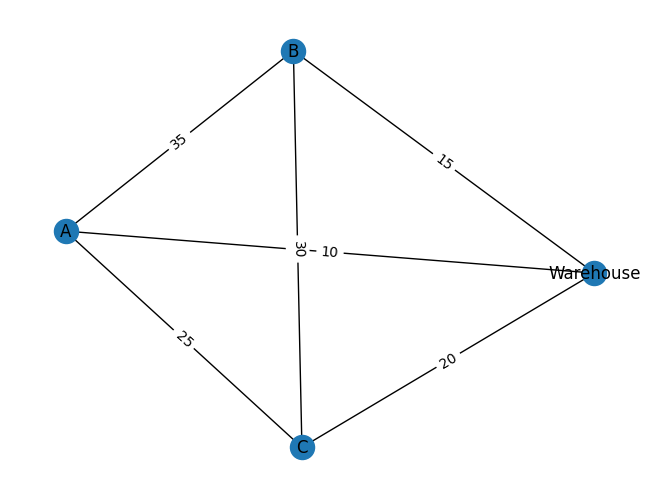

In [54]:
G = nx.Graph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)

labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()

##  Dijkstra’s Algorithm

Dijkstra’s algorithm is used to compute the shortest distance from the warehouse to all other locations.

This helps in understanding the minimum travel cost required to reach each delivery point.

In [55]:
distances = dijkstra(graph, 'Warehouse')

print("Dijkstra Shortest Paths:")
for node, dist in distances.items():
    print(f"Warehouse → {node} = {dist}")

Dijkstra Shortest Paths:
Warehouse → Warehouse = 0
Warehouse → A = 10
Warehouse → B = 15
Warehouse → C = 20


##  Minimum Spanning Tree (MST)

We use Prim’s Algorithm to construct a Minimum Spanning Tree.

The MST connects all locations with the minimum total cost, which is useful for designing efficient delivery networks.

Unlike Dijkstra, MST focuses on minimizing total edge cost rather than shortest individual paths.

In [56]:
mst, mst_cost = prim_mst(graph, 'Warehouse')

print("MST Edges:", mst)
print("MST Cost:", mst_cost)

MST Edges: [('Warehouse', 'A', 10), ('Warehouse', 'B', 15), ('Warehouse', 'C', 20)]
MST Cost: 45


##  Dijkstra vs MST Comparison

- Dijkstra computes shortest paths from a single source (Warehouse) to all nodes.
- MST connects all nodes with minimum total cost.

### Key Difference:
- Dijkstra → Best path to each node  
- MST → Best overall network

### Insight:
The shortest path to a node is not always part of the MST.  
Dijkstra is useful for routing, while MST is useful for network design.

##  Dijkstra vs MST Comparison

This graph compares the execution time of Dijkstra's algorithm and Prim's MST algorithm.

Although both are graph algorithms, they solve different problems:
- Dijkstra → shortest path
- MST → minimum total network cost

The comparison highlights their efficiency and practical usage differences.

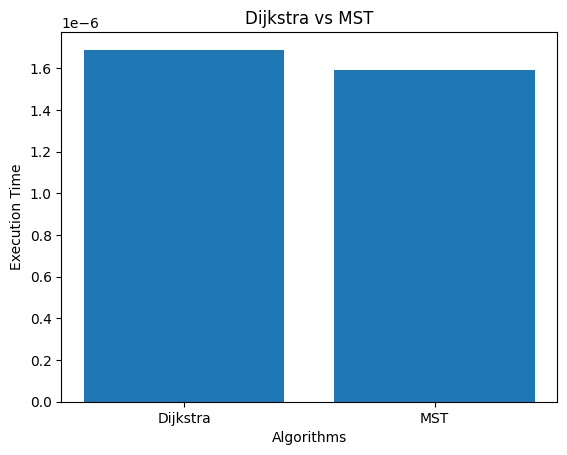

In [57]:
dijkstra_time = measure_time_avg(dijkstra, graph, 'Warehouse')
mst_time = measure_time_avg(prim_mst, graph, 'Warehouse')

labels = ['Dijkstra', 'MST']
values = [dijkstra_time, mst_time]

plt.bar(labels, values)
plt.xlabel("Algorithms")
plt.ylabel("Execution Time")
plt.title("Dijkstra vs MST")
plt.show()

##  Greedy Algorithm (Parcel Selection)

We use a greedy approach to select parcels based on value-to-weight ratio.

This ensures that we maximize total value while staying within vehicle capacity.

In [58]:
selected = select_parcels(parcels, vehicle['capacity'])
print("Selected Parcels:", selected)

Selected Parcels: [{'id': 1, 'location': 'A', 'value': 100, 'weight': 5, 'deadline': 15}, {'id': 2, 'location': 'B', 'value': 60, 'weight': 3, 'deadline': 10}]


In [59]:
delivery_nodes = [p['location'] for p in selected]
print("Delivery Nodes:", delivery_nodes)

Delivery Nodes: ['A', 'B']


##  Profit vs Weight Analysis

This graph shows how parcels are selected based on value-to-weight ratio.

Greedy algorithm prioritizes parcels that provide higher value for lower weight.

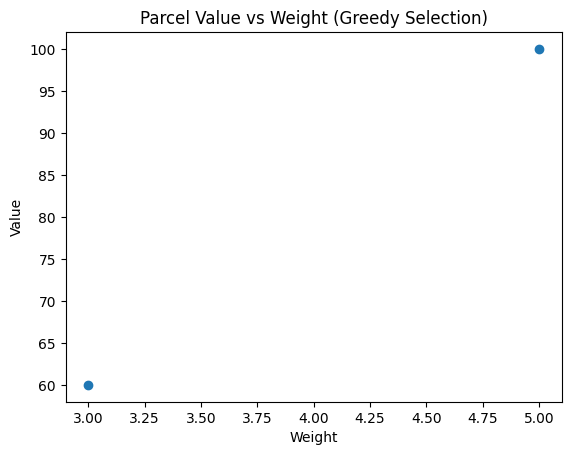

In [60]:
values = [p['value'] for p in selected]
weights = [p['weight'] for p in selected]

plt.scatter(weights, values)
plt.xlabel("Weight")
plt.ylabel("Value")
plt.title("Parcel Value vs Weight (Greedy Selection)")
plt.show()

##  Traveling Salesman Problem (TSP)

TSP is used to determine the optimal route that visits all selected delivery locations and returns to the warehouse.

This guarantees the minimum total travel distance but is computationally expensive.

In [61]:
route, cost = tsp(graph, delivery_nodes)

print("Optimal Route:", route)
print("Total Cost:", cost)

Optimal Route: ('A', 'B')
Total Cost: 60


##  Scalability Analysis (TSP)

This graph shows how execution time increases as the number of locations grows.

It demonstrates the exponential complexity of the Traveling Salesman Problem.

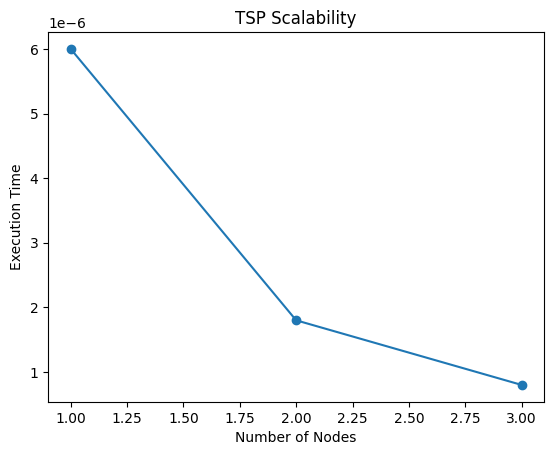

In [62]:
sizes = [1, 2, 3]
times = []

for size in sizes:
    nodes = delivery_nodes[:size]
    start = time.perf_counter()
    tsp(graph, nodes)
    times.append(time.perf_counter() - start)

plt.plot(sizes, times, marker='o')
plt.xlabel("Number of Nodes")
plt.ylabel("Execution Time")
plt.title("TSP Scalability")
plt.show()

##  Route Cost Analysis

This graph shows the cost incurred at each step of the delivery route.

It helps in identifying expensive segments in the route.

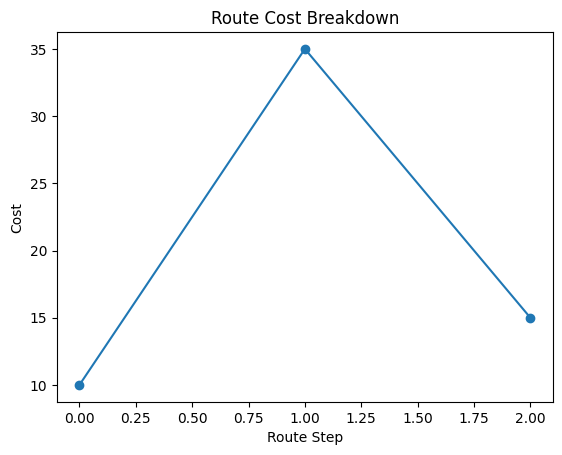

In [63]:
costs = []
nodes = ['Warehouse'] + list(route) + ['Warehouse']

for i in range(len(nodes)-1):
    costs.append(graph[nodes[i]][nodes[i+1]])

plt.plot(costs, marker='o')
plt.xlabel("Route Step")
plt.ylabel("Cost")
plt.title("Route Cost Breakdown")
plt.show()

##  Time Constraint Validation (DP Approach)

We validate whether the delivery route satisfies parcel deadlines.

This ensures that deliveries are completed within their allowed time windows.

In [65]:
deadlines = {p['location']: p['deadline'] for p in parcels}

print("Time Valid:", check_time_constraints(route, graph, deadlines))

Time Valid: False


##  Recursive Cost Calculation

A recursive approach is used to calculate the delivery route cost by exploring all possible paths.

This demonstrates the exponential nature of brute-force solutions and highlights scalability limitations.

In [66]:
rec_cost = recursive_cost(graph, 'Warehouse', delivery_nodes)
print("Recursive Cost:", rec_cost)

Recursive Cost: 60


##  DP vs Recursion Comparison

This graph compares the execution time of Dynamic Programming (time constraint validation) and the recursive approach.

It highlights how recursion becomes inefficient due to repeated computations, while DP provides a more efficient way to handle constraints.

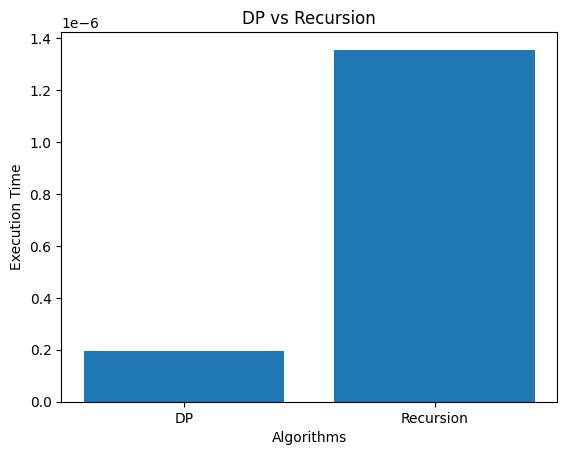

In [67]:
dp_time = measure_time_avg(check_time_constraints, route, graph, deadlines)
rec_time = measure_time_avg(recursive_cost, graph, 'Warehouse', delivery_nodes)

labels = ['DP', 'Recursion']
values = [dp_time, rec_time]

plt.bar(labels, values)
plt.xlabel("Algorithms")
plt.ylabel("Execution Time")
plt.title("DP vs Recursion")
plt.show()

##  Algorithm Time Comparison

We compare execution times of different algorithms:
- Greedy
- TSP
- Recursion

Since the dataset is small, execution times are in microseconds, but relative differences highlight performance trade-offs.

In [68]:
times = {}

# Greedy
times['Greedy'] = measure_time_avg(select_parcels, parcels, vehicle['capacity'])

# TSP
times['TSP'] = measure_time_avg(tsp, graph, delivery_nodes)

# Recursion
times['Recursion'] = measure_time_avg(recursive_cost, graph, 'Warehouse', delivery_nodes)

print(times)

{'Greedy': 6.189000014273916e-07, 'TSP': 6.353999415296129e-07, 'Recursion': 1.560800024890341e-06}


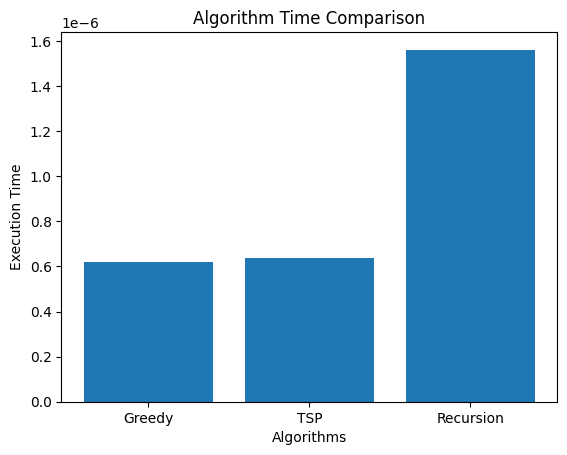

In [69]:
plt.bar(times.keys(), times.values())
plt.xlabel("Algorithms")
plt.ylabel("Execution Time")
plt.title("Algorithm Time Comparison")
plt.show()

##  Observations & Analysis

### 🔹 Performance Comparison
- The **Greedy algorithm** is the fastest among all approaches due to its simple sorting-based logic.
- The **TSP algorithm** takes more time as it explores all possible permutations to find the optimal route.
- The **Recursive approach** is the slowest because it follows an exponential time complexity, making it inefficient for larger inputs.



### 🔹 Optimality vs Efficiency
- The **Greedy method** provides a quick solution but does not guarantee global optimality.
- The **TSP approach** guarantees the optimal route but at the cost of higher computation time.
- This demonstrates a key trade-off between **speed and accuracy**.



### 🔹 Graph Algorithm Insights
- **Dijkstra’s algorithm** efficiently computes the shortest path from the warehouse to individual locations.
- **Minimum Spanning Tree (MST)** minimizes the total cost required to connect all nodes.
- The shortest paths obtained from Dijkstra are not necessarily part of the MST, as both algorithms optimize different objectives.



### 🔹 Constraint Handling
- The **DP-based validation** ensures that delivery deadlines are satisfied.
- This step highlights the importance of incorporating real-world constraints into algorithmic solutions.



### 🔹 Scalability Insight
- As the number of delivery locations increases, the execution time of TSP grows rapidly.
- This confirms that TSP is **not scalable** for large datasets and requires approximation methods in real-world systems.



### 🔹 Overall Insight
- No single algorithm is sufficient for solving complex logistics problems.
- A **hybrid approach**, combining greedy selection, graph algorithms, and optimization techniques, provides the most effective solution.

##  Algorithm Comparison Summary

This table summarizes the performance and characteristics of all algorithms used in the project.

In [71]:
import pandas as pd

data = {
    "Algorithm": ["Greedy", "DP", "Recursion", "Dijkstra", "MST", "TSP"],
    "Speed": ["Fast", "Fast", "Slow", "Fast", "Fast", "Slow"],
    "Optimality": ["No", "Constraint-based", "Yes", "Yes", "Yes", "Yes"],
    "Scalability": ["High", "High", "Low", "High", "High", "Low"]
}

df = pd.DataFrame(data)
df

,Algorithm,Speed,Optimality,Scalability
0,Greedy,Fast,No,High
1,DP,Fast,Constraint-based,High
2,Recursion,Slow,Yes,Low
3,Dijkstra,Fast,Yes,High
4,MST,Fast,Yes,High
5,TSP,Slow,Yes,Low


In [70]:
# Total delivery value and weight

total_value = sum(p['value'] for p in selected)
total_weight = sum(p['weight'] for p in selected)

print("Total Delivery Value:", total_value)
print("Total Weight Used:", total_weight)

Total Delivery Value: 160
Total Weight Used: 8


##  Conclusion

This project demonstrates how multiple algorithmic techniques can be combined to solve a real-world logistics problem efficiently.

By integrating Greedy, Dynamic Programming, Graph Algorithms (Dijkstra & MST), TSP, and Recursion, we were able to model and optimize delivery routes under various constraints such as distance, time, and capacity.

---

##  Final Results

- **Total Delivery Value:** 160  
- **Total Weight Used:** 8  

This shows that the system successfully maximizes value while respecting vehicle constraints.

---

##  Key Learnings

- Greedy algorithms provide fast and efficient solutions but may not always be globally optimal.  
- TSP ensures optimal routing but has high computational complexity.  
- Recursive approaches demonstrate exponential growth and are not scalable.  
- Dijkstra helps in shortest path computation, while MST minimizes total network cost.  
- Combining multiple strategies leads to better decision-making in complex systems.

---

##  Future Improvements

- Multi-vehicle delivery optimization  
- Real-time traffic and dynamic routing  
- Fuel cost and resource optimization  
- Scaling for larger datasets using heuristic or approximation algorithms  

---

##  Final Insight

This project highlights the trade-off between **efficiency and optimality**, showing that no single algorithm is sufficient — instead, a hybrid approach provides the best results.